In [1]:
import torch
from torch.utils.data import DataLoader
import os
import numpy as np
import random
import statistics

In [2]:
from data.audio_preprocessor import AudioPreprocessor
from data.speech_commands_ds import SpeechCommandsDataset
from nets.vgg import VGG1D
from nets.resnet import ResNet1D
from nets.ensemble import Ensemble
from model.testing import test_model

In [3]:
data_dir = 'C:/Users/weron/Pulpit/sem1/dl/proj1/Deep-Learning/transformers/dataset/train'

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
def load_model(model, model_path):

    model.load_state_dict(torch.load(model_path))
    model = model.to(device)
    return model

def load_general_models(general_models_paths):

    models = []

    for model_path in general_models_paths:
        if 'vgg' in model_path:
            model = VGG1D()
        else:
            model = ResNet1D()

        models.append(load_model(model, model_path))

    return models

In [6]:

general_models_paths = {
    './experiments/1d_resnet/lr_0_0001/rs_24/best_model.pt', # best accuracy
    './experiments/1d_resnet/base/rs_24/best_model.pt', # best unknown
    './experiments/1d_resnet/epochs_100/rs_24/best_model.pt', # best unknown
    './experiments/1d_resnet/epochs_50/rs_24/best_model.pt', # best unknown
    './experiments/1d_vgg/epochs_50/rs_24/best_model.pt', # best accuracy
    './experiments/1d_vgg/wd_0_001/rs_24/best_model.pt', # best silence, best unknown
}
general_models = load_general_models(general_models_paths)

vsu_model_path = './experiments/1d_vgg_vsu/base/rs_24/best_model.pt'
vsu_model = VGG1D(3)
vsu_model = load_model(vsu_model, vsu_model_path)

ensemble = Ensemble(general_models, vsu_model)

In [7]:
root_dir = os.path.join('experiments', 'ensemble')
os.makedirs(root_dir, exist_ok=True)

Accuracy: 0.8560
Accuracy: 0.8560
Accuracy: 0.8560
Mean Acc = 0.856020942408377, Std Acc = 0.0
(Run 1 Acc = 0.856020942408377 | Run 2 Acc = 0.856020942408377 | Run 3 Acc = 0.856020942408377)


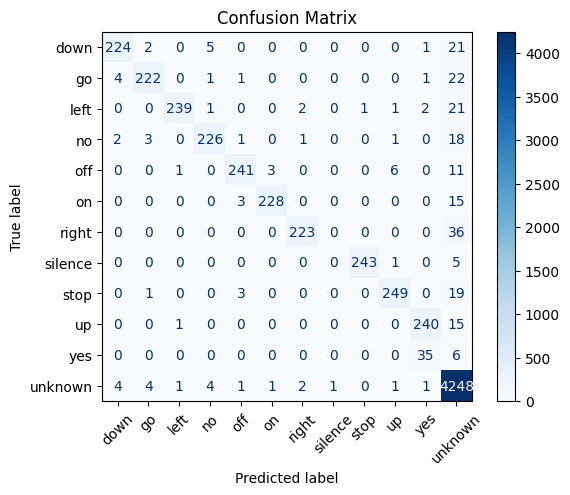

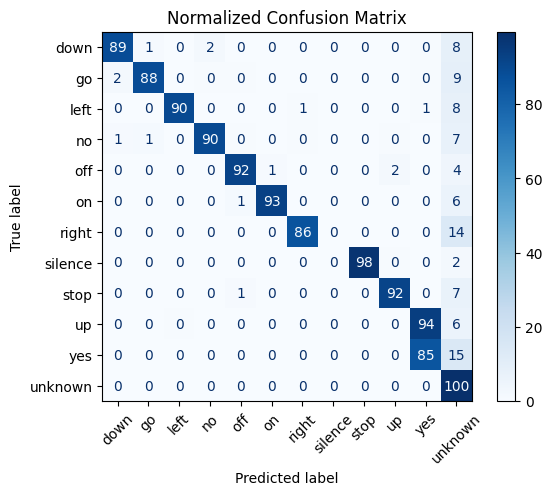

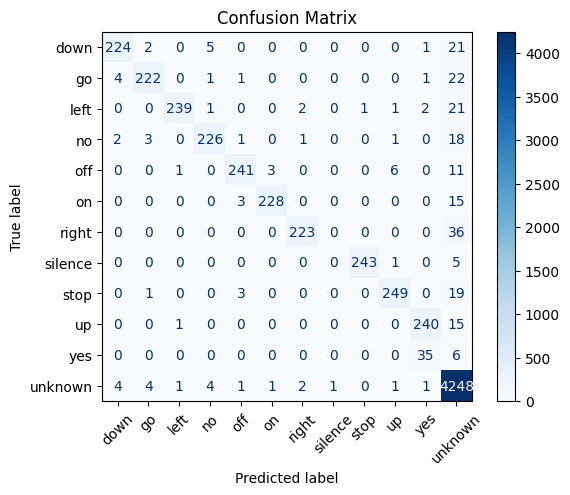

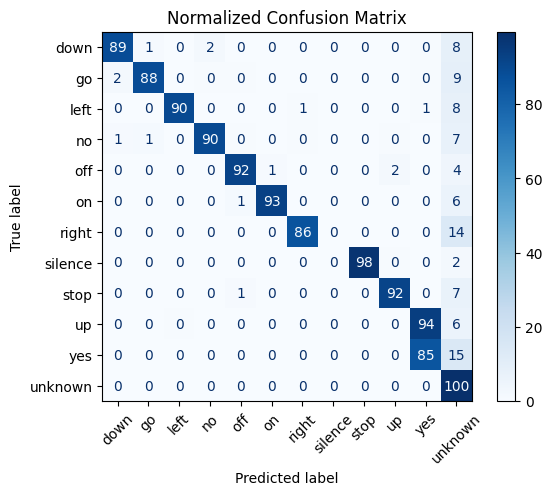

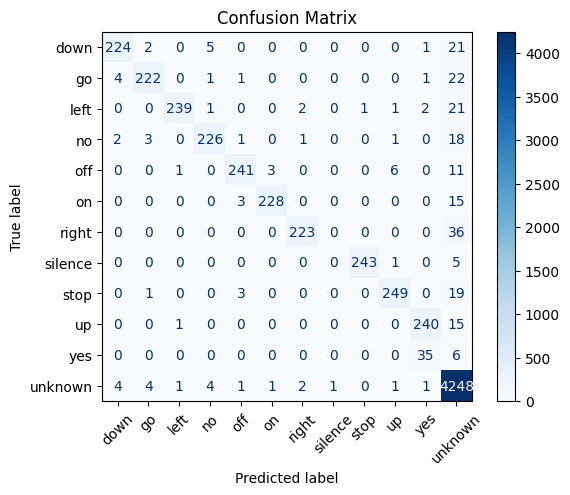

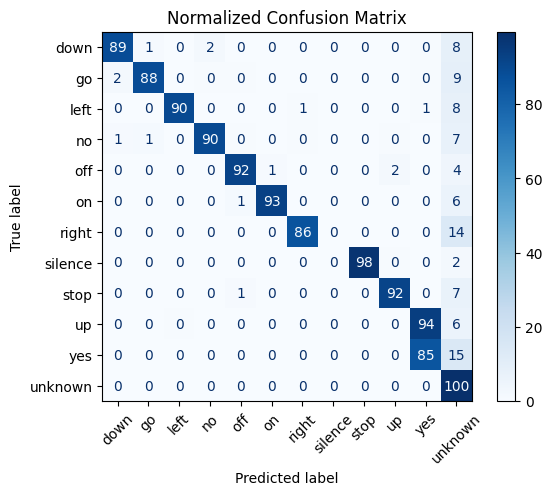

In [ ]:
run_accuracies = []

for i in [42, 24, 62]:

    # Set random seed
    random_seed = i
    random.seed(random_seed)
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(random_seed)

    preprocessor = AudioPreprocessor()

    test_dataset = SpeechCommandsDataset(
        root_dir=data_dir,
        file_list_path='testing_list.txt',
        mode='1d',
        vsu=False,
        preprocessor=preprocessor,
        augment=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=32,
        shuffle=True,
        num_workers=0
    )

    folder = os.path.join(root_dir, f'rs_{i}')
    test_acc = test_model(ensemble, test_loader, device, './experiments/ensemble', 
                ['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes', 'silence', 'unknown'])
    
    run_accuracies.append(test_acc)

mean_acc = statistics.mean(run_accuracies)
std_acc = statistics.stdev(run_accuracies)
print(f'Mean Acc = {mean_acc}, Std Acc = {std_acc}')
print(f'(Run 1 Acc = {run_accuracies[0]} | Run 2 Acc = {run_accuracies[1]} | Run 3 Acc = {run_accuracies[2]})')